# EfficientNetB2 para clasificacion de aves CUB-200-2011


## 1. Importar librerias y configurar parametros


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.efficientnet import EfficientNetB2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
DATASET_NAME = "caltech_birds2011"
IMG_SIZE = 260
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-4
DROPOUT_RATE = 0.20

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Dataset cache:", TFDS_DATA_DIR)


2026-06-28 20:30:20.462974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-28 20:30:21.120862: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-28 20:30:24.058888: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.

Aqui definimos en que proporcion dividimos los datos haciendo uso del metodo de `División Fija`


In [2]:

TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases de pajaros: {num_classes}")
print(f"Cantidad de datos para Entrenar: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Cantidad de datos para Validación: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Cantidad de datos para Test: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")


Splits: train[:80%] train[80%:] test
Clases de pajaros: 200
Cantidad de datos para Entrenar: 4795
Cantidad de datos para Validación: 1199
Cantidad de datos para Test: 5794


I0000 00:00:1782678630.974882   42689 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 3. Visualizar algunas imagenes del dataset


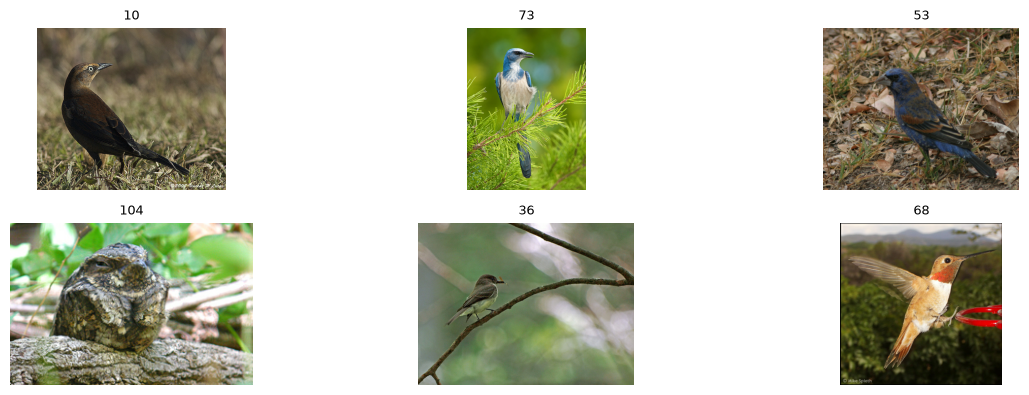

In [14]:
plt.figure(figsize=(12, 6))
for i, (imagen, etiqueta) in enumerate(ds_train_raw.take(6)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagen)
    plt.title(class_names[int(etiqueta.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [3]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesar datos

CUB tiene imagenes de tamaños variables. Usamos `resize_with_pad` para llevarlas a `260x260` sin deformar la proporcion. EfficientNetB2 espera imagenes en el rango `[0, 255]` y aplica su propia normalizacion dentro del modelo, por lo que no usamos `preprocess_input` (es un no-op): basta con entregar la imagen como `float32` en ese rango.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(imagen, etiqueta):
    """
    Normalizamos las imagenes, las adaptamos a como las pide el modelo y preparamos su etiqueta.

    Args:
        imagen: Tensor con la imagen original de CUB-200-2011.
        etiqueta: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada y etiqueta entera.
    """

    imagen = tf.image.resize_with_pad(imagen, IMG_SIZE, IMG_SIZE)
    imagen = tf.cast(imagen, tf.float32)
    etiqueta = tf.cast(etiqueta, tf.int32)
    return imagen, etiqueta


def prepare_dataset(dataset, training=False):
    """

    Aplica el preprocesamiento a todos los conjuntos del dataset. Si se indica entrenamiento, 
    mezcla los ejemplos antes de agruparlos en batches. 
    Prefetch prepara un batch y lo manda a entrenar, en paralelo prepara el siguiente Batch.

    Args:
        dataset: Dataset de TensorFlow con pares (imagen, etiqueta).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset: Dataset listo para ser consumido por model.fit o model.evaluate.
    """

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
        
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch de imagenes:", images.shape)
    print("Batch de etiquetas:", labels.shape)
    print("Label dtype:", labels.dtype)


2026-06-28 20:30:42.681738: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Batch de imagenes: (8, 260, 260, 3)
Batch de etiquetas: (8,)
Label dtype: <dtype: 'int32'>


2026-06-28 20:30:45.554801: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5.b Data augmentation

Para mejorar la generalizacion y reducir el overfitting aplicamos *data augmentation*: transformaciones aleatorias sobre las imagenes de entrenamiento. Las definimos como capas de Keras dentro del modelo, por lo que **solo se activan durante el entrenamiento** (`model.fit`) y quedan inactivas en validacion, evaluacion y prediccion.

- `RandomFlip("horizontal")`: refleja la imagen de izquierda a derecha. No usamos flip vertical porque un ave no aparece boca abajo.
- `RandomRotation(0.10)`: rota levemente la imagen (~+-10%).
- `RandomZoom(0.10)`: acerca o aleja levemente.
- `RandomContrast(0.10)`: varia el contraste.

Usamos `fill_mode="reflect"` para que las rotaciones y el zoom no dejen bordes con relleno gris. La aumentacion opera sobre la imagen en el rango `[0, 255]`, antes de la normalizacion interna que EfficientNetB2 aplica dentro del modelo.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10, fill_mode="reflect"),
        layers.RandomZoom(0.10, fill_mode="reflect"),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

In [ ]:
# Visualizamos varias versiones aumentadas de una misma imagen de entrenamiento.
for sample_image, _ in ds_train_raw.take(1):
    sample = tf.image.resize_with_pad(tf.cast(sample_image, tf.float32), IMG_SIZE, IMG_SIZE)

plt.figure(figsize=(12, 6))
for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.tight_layout()
plt.show()

## 6. Definir el modelo base


In [5]:
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
#x = data_augmentation(inputs)
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name="EfficientNetB2")
model.summary()

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "EfficientNetB2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       281,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,050,369 (30.71 MB)

 Trainable params: 281,800 (1.07 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

## 7. Compilar y entrenar el modelo
Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`


Epoch 1/30


2026-06-28 20:31:37.919122: I external/local_xla/xla/service/service.cc:163] XLA service 0x7bd53c001ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-28 20:31:37.919158: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-28 20:31:38.802476: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-28 20:31:44.357704: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-28 20:31:54.362773: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 20:31:58.183574: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm

600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0309 - loss: 5.1805

2026-06-28 20:33:32.584121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 20:33:32.772885: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 20:33:32.990322: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 20:33:33.193110: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 20:33:33.302547: E external/local_xla/xla/service

600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 137ms/step - accuracy: 0.0649 - loss: 4.9643 - val_accuracy: 0.1785 - val_loss: 4.5422
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.2926 - loss: 4.1259 - val_accuracy: 0.3294 - val_loss: 3.9114
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.4409 - loss: 3.5003 - val_accuracy: 0.4087 - val_loss: 3.4255
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.5470 - loss: 3.0209 - val_accuracy: 0.4595 - val_loss: 3.0542
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.6060 - loss: 2.6380 - val_accuracy: 0.4979 - val_loss: 2.7639
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.6546 - loss: 2.3425 - val_accuracy: 0.5263 - val_loss: 2.5359
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.6953 - loss: 2.1098 - val_accuracy: 0.5505 - val_loss: 2.3533
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.7230 - loss: 1.9070 - val_accur

2026-06-28 20:42:11.119822: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 6489632 bytes after encountering the first element of size 6489632 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.8749 - loss: 0.8369 - val_accuracy: 0.6497 - val_loss: 1.4476
Epoch 22/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8782 - loss: 0.8026 - val_accuracy: 0.6564 - val_loss: 1.4228
Epoch 23/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8832 - loss: 0.7686 - val_accuracy: 0.6597 - val_loss: 1.4048
Epoch 24/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.8882 - loss: 0.7315 - val_accuracy: 0.6597 - val_loss: 1.3846
Epoch 25/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.8974 - loss: 0.7029 - val_accuracy: 0.6656 - val_loss: 1.3696
Epoch 26/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.9024 - loss: 0.6760 - val_accuracy: 0.6597 - val_loss: 1.3546
Epoch 27/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.9072 - loss: 0.6477 - val_accuracy: 0.6697 - val_loss: 1.3405
Epoch 28/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9114 - loss: 0.6185 - val_

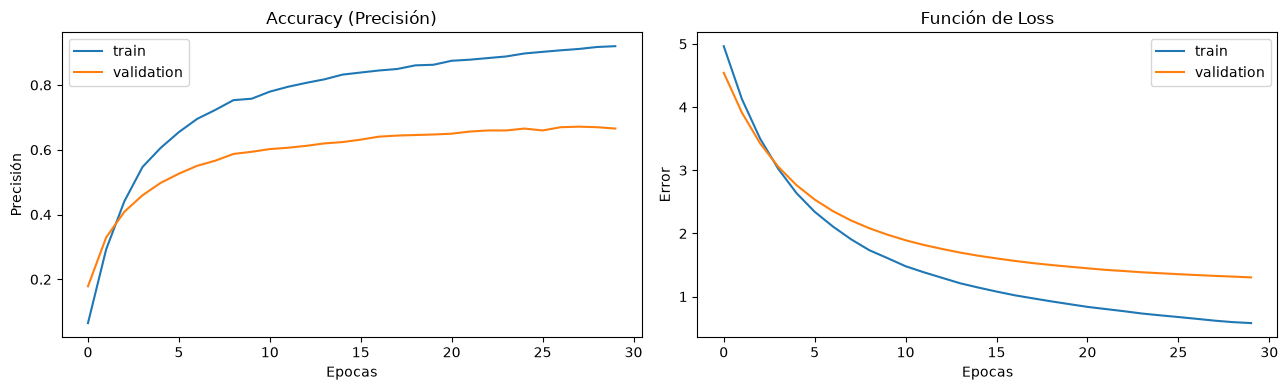

,accuracy,loss,val_accuracy,val_loss
0,0.064859,4.964285,0.178482,4.542236
1,0.292596,4.125854,0.329441,3.911355
2,0.440876,3.500255,0.408674,3.425527
3,0.547028,3.020877,0.459550,3.054211
4,0.606048,2.638010,0.497915,2.763908
5,0.654640,2.342544,0.526272,2.535949
6,0.695308,2.109819,0.550459,2.353323
7,0.723045,1.907024,0.566305,2.204478
8,0.753285,1.734727,0.587156,2.082533
9,0.757664,1.609287,0.593828,1.979990


In [6]:

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)


## 9. Evaluacion directa en conjunto de prueba


In [7]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


725/725 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.6969 - loss: 1.2325
Metricas en conjunto de prueba:
loss: 1.2325
compile_metrics: 0.6969


## 10. Matriz de confusion y reporte de clasificacion


In [8]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


2026-06-28 20:52:47.510378: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


725/725 ━━━━━━━━━━━━━━━━━━━━ 49s 50ms/step
Accuracy en test (EfficientNetB2): 0.6969


,precision,recall,f1-score,support
0,0.956522,0.733333,0.830189,30.000000
1,0.821429,0.766667,0.793103,30.000000
2,0.619048,0.928571,0.742857,28.000000
3,0.771429,0.900000,0.830769,30.000000
4,0.923077,0.857143,0.888889,14.000000
...,...,...,...,...
198,0.742857,0.866667,0.800000,30.000000
199,0.827586,0.800000,0.813559,30.000000
accuracy,0.696928,0.696928,0.696928,0.696928
macro avg,0.706432,0.699735,0.697958,5794.000000


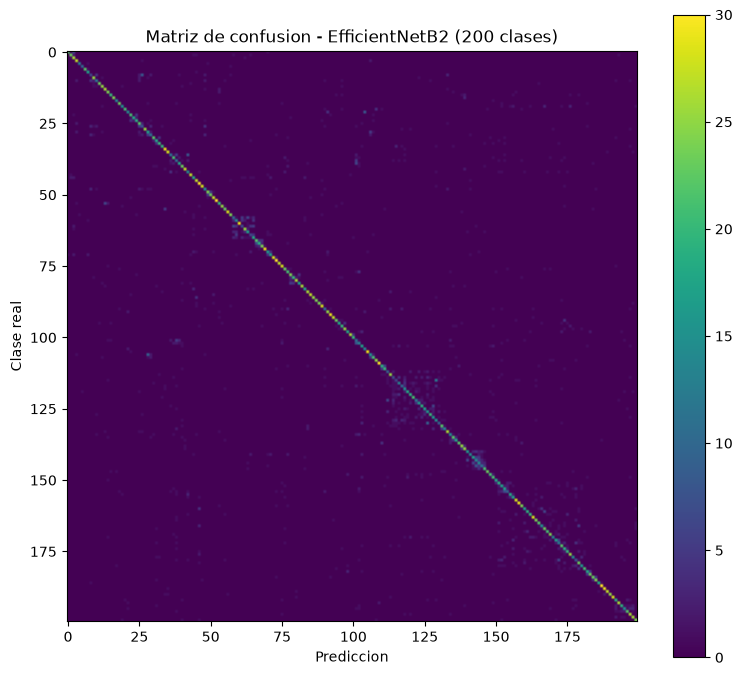

Top 10 pares mas confundidos:
  '115' confundida con '129': 12 veces
  '130' confundida con '126': 9 veces
  '106' confundida con '28': 9 veces
  '145' confundida con '143': 8 veces
  '102' confundida con '101': 8 veces
  '36' confundida con '42': 8 veces
  '21' confundida con '104': 8 veces
  '8' confundida con '26': 8 veces
  '154' confundida con '153': 7 veces
  '67' confundida con '66': 7 veces


In [9]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 11. Guardar resultados y modelo


In [ ]:
results = {
    "modelo": "EfficientNetB2",
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history.history["loss"]),
    "learning_rate": LEARNING_RATE,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / "efficientnetb2_simple_results.csv"
model_path = MODELS_DIR / "efficientnetb2_cub200.keras"

results_df.to_csv(results_path, index=False)
model.save(model_path)

print("Resultados guardados en:", results_path)
print("Modelo guardado en:", model_path)